# Lab2 - Linear Model

This lab uses linear regression for inference and prediction. The first problem studies relationships between earnings and socioeconomic variables. The second problem builds predictive models for concrete strength.

The analysis uses the supplied data files. They are downloaded when needed and saved in `Labs/Lab2_Linear_Model/datasource/`. All code needed to reproduce the analysis is included in the notebook.

The notebook reports compact results tables, visual diagnostics, model selection criteria, and held out test set performance.

In [3]:
#%pip install numpy pandas matplotlib seaborn statsmodels scikit-learn

In [ ]:
from pathlib import Path
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" 
              in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

DATA_DIR = Path("datasource")
DATA_DIR.mkdir(parents=True, exist_ok=True)

RAW_BASE = "https://raw.githubusercontent.com/georgehagstrom/" \
"DATA622Fall2026/main/website/assignments/labs/labData"

files = {
    "earnings": f"{RAW_BASE}/earnings.csv",
    "earnings_dictionary": f"{RAW_BASE}/earnings_dictionary.qmd",
    "concrete_train": f"{RAW_BASE}/concrete_train.csv",
    "concrete_test": f"{RAW_BASE}/concrete_test.csv",
    "dictionary": f"{RAW_BASE}/concrete_dictionary.txt",
}

for name, url in files.items():
    if name == "earnings_dictionary":
        target = DATA_DIR / "earnings_dictionary.qmd"
    elif name in {"earnings", "concrete_train", "concrete_test"}:
        target = DATA_DIR / f"lab2_{name}.csv"
    else:
        target = DATA_DIR / "concrete_dictionary.txt"

    if not target.exists():
        data = urlopen(url).read()
        target.write_bytes(data)
    print(f"ready: {target}")

LAB2_DATA_DIR = DATA_DIR

ready: datasource\lab2_earnings.csv
ready: datasource\earnings_dictionary.qmd
ready: datasource\lab2_concrete_train.csv
ready: datasource\lab2_concrete_test.csv
ready: datasource\concrete_dictionary.txt


# Problem 1: Confounds in Earnings Data

The goal of this problem is to understand which socioeconomic factors have an effect on earnings.

**Dataset description (earnings.csv):** The earnings data are from the Work, Family, and Well Being in the United States, 1990 survey. The official data dictionary is available at the course GitHub repo and describes the variables used in this analysis.

- `height`: height in inches; values above 83 inches are coded as missing
- `weight`: weight in pounds; very large values and missing/unknown responses are coded as missing
- `male`: 1 = Male, 0 = Female
- `earn`: personal income in dollars before taxes
- `earnk`: personal income in thousands of dollars (`earn / 1000`)
- `ethnicity`: `Hispanic`, `White`, `Black`, or `Other`
- `education`: highest grade completed, from 0 (None) to 18 (Graduate or professional degree)
- `mother_education`: highest grade completed, from 0 (None) to 18 (Graduate or professional degree)
- `father_education`: highest grade completed, from 0 (None) to 18 (Graduate or professional degree)
- `walk`: ordinal measure of walking frequency, coded as:

| Code | Meaning |
| --- | --- |
| 1 | Never |
| 2 | Once a month or less |
| 3 | About twice a month |
| 4 | About once a week |
| 5 | Twice a week |
| 6 | Three times a week |
| 7 | More than 3 times a week |
- `exercise`: frequency of strenuous exercise, coded as:

| Code | Meaning |
| --- | --- |
| 1 | Never |
| 2 | Once a month or less |
| 3 | About twice a month |
| 4 | About once a week |
| 5 | Twice a week |
| 7 | More than 3 times a week |
| 8 | Every day |
- `smokenow`: current smoking status, with 1 = Yes, 2 = No
- `tense`: number of days the respondent felt tense or anxious in the past 7 days
- `angry`: number of days the respondent felt angry in the past 7 days, ranging from 0 to 7
- `age`: age in years in 1990

The official dictionary for the earnings data can be read in the [course data dictionary](https://raw.githubusercontent.com/georgehagstrom/DATA622Fall2026/main/website/assignments/labs/labData/earnings_dictionary.qmd).

## 1a. Missing Values and Transformations

### Load and inspect the data

In [5]:
earnings_path = LAB2_DATA_DIR / "lab2_earnings.csv"
earnings = pd.read_csv(earnings_path)

earnings.head()

,height,weight,male,earn,earnk,ethnicity,education,mother_education,father_education,walk,exercise,smokenow,tense,angry,age
0,74,210.0,1,50000.0,50.0,White,16.0,12.0,12.0,3,3,2.0,2.0,0,45
1,66,125.0,0,60000.0,60.0,White,16.0,12.0,12.0,6,5,1.0,0.0,0,58
2,64,126.0,0,30000.0,30.0,White,16.0,12.0,12.0,8,1,2.0,7.0,1,29
3,65,200.0,0,25000.0,25.0,White,17.0,12.0,NaN,8,1,2.0,1.0,0,57
4,63,110.0,0,50000.0,50.0,Other,16.0,15.0,12.0,5,6,2.0,7.0,1,91


In [ ]:
#earnings.info()
earnings.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   height            1816 non-null   int64  
 1   weight            1789 non-null   float64
 2   male              1816 non-null   int64  
 3   earn              1816 non-null   float64
 4   earnk             1816 non-null   float64
 5   ethnicity         1816 non-null   object 
 6   education         1814 non-null   float64
 7   mother_education  1572 non-null   float64
 8   father_education  1521 non-null   float64
 9   walk              1816 non-null   int64  
 10  exercise          1816 non-null   int64  
 11  smokenow          1815 non-null   float64
 12  tense             1814 non-null   float64
 13  angry             1816 non-null   int64  
 14  age               1816 non-null   int64  
dtypes: float64(8), int64(6), object(1)
memory usage: 212.9+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
height,1816.0,NaN,NaN,NaN,66.568833,3.831822,57.0,64.0,66.0,69.25,82.0
weight,1789.0,NaN,NaN,NaN,156.305198,34.617059,80.0,130.0,150.0,180.0,342.0
male,1816.0,NaN,NaN,NaN,0.371696,0.483391,0.0,0.0,0.0,1.0,1.0
earn,1816.0,NaN,NaN,NaN,21147.296256,22531.765123,0.0,6000.0,16000.0,27000.0,400000.0
earnk,1816.0,NaN,NaN,NaN,21.147296,22.531765,0.0,6.0,16.0,27.0,400.0
ethnicity,1816,4,White,1494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,1814.0,NaN,NaN,NaN,13.235391,2.556638,2.0,12.0,12.0,15.0,18.0
mother_education,1572.0,NaN,NaN,NaN,11.192112,3.150983,0.0,9.0,12.0,12.0,18.0
father_education,1521.0,NaN,NaN,NaN,11.218935,3.726337,0.0,8.0,12.0,13.0,18.0
walk,1816.0,NaN,NaN,NaN,5.303414,2.601104,1.0,3.0,6.0,8.0,8.0


### Distribution of earnings

The variable `earnk` is strongly right skewed: most respondents have relatively low earnings, while a smaller group has much larger earnings. This pattern is common in income data and creates a long right tail in the histogram.

Because of this skewness, it is often preferable to model `log_earnk` instead of `earnk` directly. The log transformation compresses the upper tail and makes the relationship with predictors more stable and easier to interpret for linear regression.

A log transformed model is especially useful when we want to describe the typical relationship for people with positive earnings, while recognizing that zero and missing earnings are excluded from that subset.


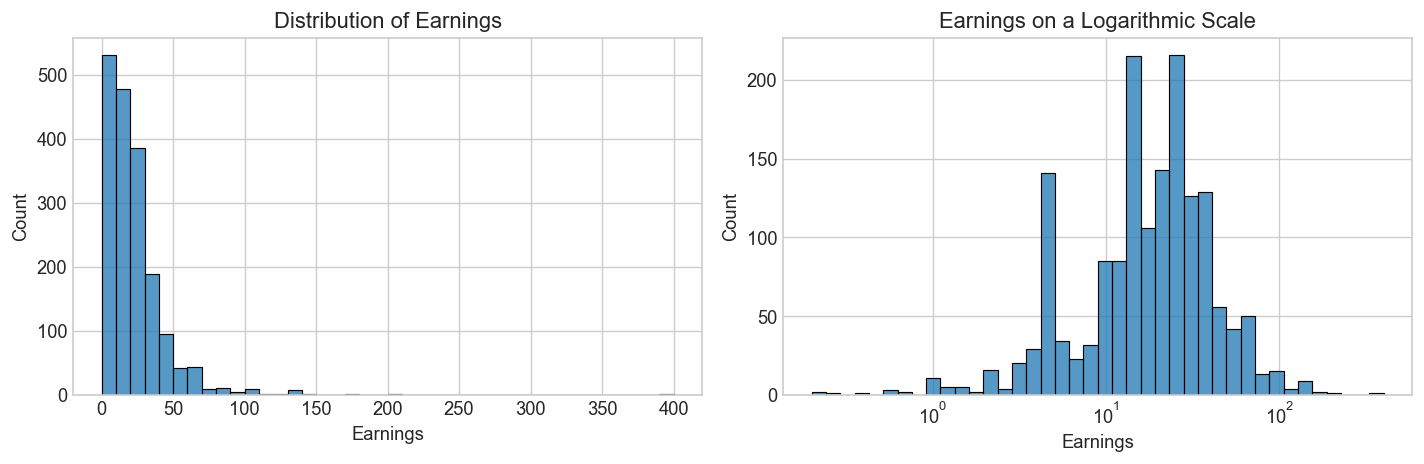

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=earnings, x="earnk", bins=40, ax=axes[0])
axes[0].set_title("Distribution of Earnings")
axes[0].set_xlabel("Earnings")

sns.histplot(data=earnings, x="earnk", bins=40, log_scale=True, ax=axes[1])
axes[1].set_title("Earnings on a Logarithmic Scale")
axes[1].set_xlabel("Earnings")

plt.tight_layout()
plt.show()

The earnings distribution is strongly right skewed. Most respondents have relatively low earnings, while a smaller number have substantially higher earnings, creating a long right tail. Therefore, modeling `log_earnk` may provide a more balanced and stable response variable.

### Missing values and the target transformation

**Question**

Describe the amount and pattern of missing data. Explain how missing values are handled and how that choice affects the population represented by the model.

Discuss the advantages and disadvantages of modeling `earnk` directly versus modeling `log_earnk`. If zero earnings are removed before taking the logarithm, explain that the resulting model describes people with positive earnings rather than the full survey population.

**Resolution**

In [8]:
missing_summary = earnings.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

father_education    295
mother_education    244
weight               27
education             2
tense                 2
smokenow              1
dtype: int64

A new dataset will be created with only positive earnings to create a new log

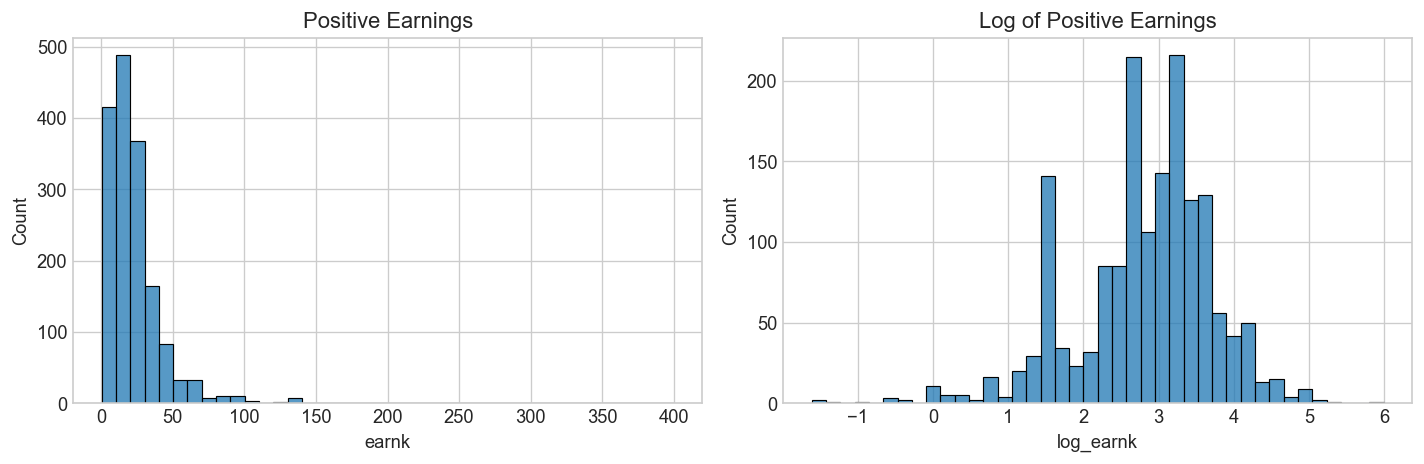

In [9]:
positive_earnings = earnings.loc[earnings["earnk"] > 0].copy()
positive_earnings["log_earnk"] = np.log(positive_earnings["earnk"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=positive_earnings, x="earnk", bins=40, ax=axes[0])
sns.histplot(data=positive_earnings, x="log_earnk", bins=40, ax=axes[1])
axes[0].set_title("Positive Earnings")
axes[1].set_title("Log of Positive Earnings")
plt.tight_layout()
plt.show()

After restricting to positive earnings, the distribution is much more regular and the log transformed plot appears much closer to a symmetric bell shape than the original earnings scale. This indicates that the right skewness in `earnk` is largely being driven by a long upper tail of high earners rather than by a fundamentally different pattern in the rest of the sample.

This is why we will use `log_earnk` in the subsequent models: it stabilizes the variance and makes the linear model more interpretable. At the same time, we should remember that this analysis now describes the population of respondents with positive earnings only, not the full survey sample.

## 1b. Height and Weight Confounds

Fit separate models for height and weight, then fit a model containing both variables. Report coefficients and confidence intervals. Explain how the confidence intervals change when both predictors are included.

**Dependent variable:** `log_earnk`, the natural logarithm of positive earnings in thousands of dollars.

**Independent variables (predictors):** `height` and `weight`.

Three models will be estimated:

1. `log_earnk ~ height`
2. `log_earnk ~ weight`
3. `log_earnk ~ height + weight`

The first two models estimate separate associations, while the third estimates the association of each body measurement after adjusting for the other.Predictors:
    

In [10]:
# Create a compact coefficient and confidence interval table for a fitted model.
def coefficient_table(model, terms=None):
    if terms is None:
        terms = list(model.params.index)

    confidence_intervals = model.conf_int().loc[terms]
    table = pd.DataFrame({
        "coefficient": model.params.loc[terms],
        "standard_error": model.bse.loc[terms],
        "p_value": model.pvalues.loc[terms],
        "ci_lower": confidence_intervals[0],
        "ci_upper": confidence_intervals[1],
        "r_squared": model.rsquared,
    })
    return table


height_model = smf.ols("log_earnk ~ height", data=positive_earnings).fit()
coefficient_table(height_model, ["height"])

,coefficient,standard_error,p_value,ci_lower,ci_upper,r_squared
height,0.057039,0.00562,1.645430e-23,0.046016,0.068062,0.059542


In [11]:
coefficient_table(height_model, ["height"])

,coefficient,standard_error,p_value,ci_lower,ci_upper,r_squared
height,0.057039,0.00562,1.645430e-23,0.046016,0.068062,0.059542


- **Effect size:** The height only model estimates a positive association: a one unit increase in height corresponds to approximately a 5.7% difference in expected earnings on the log earnings scale.

- **Statistical evidence:** The coefficient is estimated precisely in this sample (`p < 0.001`), so the data are inconsistent with a zero linear association under this model. This is evidence of association, not proof of causation.

- **Explanatory power:** Height alone explains about 6.0% of the variation in log earnings (`R^2 = 0.060`), so it is statistically detectable but still a weak predictor of individual earnings.

In [12]:
# Fit the weight only model and report only the relevant results.
weight_model = smf.ols("log_earnk ~ weight", data=positive_earnings).fit()
coefficient_table(weight_model, ["weight"])

,coefficient,standard_error,p_value,ci_lower,ci_upper,r_squared
weight,0.004079,0.000646,3.527337e-10,0.002812,0.005347,0.024232


In [13]:
coefficient_table(weight_model, ["weight"])

,coefficient,standard_error,p_value,ci_lower,ci_upper,r_squared
weight,0.004079,0.000646,3.527337e-10,0.002812,0.005347,0.024232


- **Effect size:** The weight only model estimates that a one unit increase in weight corresponds to approximately a 0.41% difference in expected earnings.

- **Statistical evidence:** The coefficient is estimated precisely in this sample (`p < 0.001`), indicating evidence of a nonzero association under this one predictor model. This should not be interpreted as a causal effect.

- **Explanatory power:** Weight alone explains about 2.4% of the variation in log earnings (`R^2 = 0.024`), making it a weak predictor and less informative than height by itself.

In [14]:
# Fit the model with both body size predictors.
both_model = smf.ols("log_earnk ~ height + weight", data=positive_earnings).fit()
coefficient_table(both_model, ["weight", "height"])

,coefficient,standard_error,p_value,ci_lower,ci_upper,r_squared
weight,0.000660,0.000772,3.926746e-01,-0.000854,0.002173,0.059786
height,0.053588,0.006881,1.211967e-14,0.040092,0.067084,0.059786


In [15]:
coefficient_table(both_model, ["weight", "height"])

,coefficient,standard_error,p_value,ci_lower,ci_upper,r_squared
weight,0.000660,0.000772,3.926746e-01,-0.000854,0.002173,0.059786
height,0.053588,0.006881,1.211967e-14,0.040092,0.067084,0.059786


- In the combined model, height remains positively associated with earnings, with an estimated coefficient of approximately `0.0536`. Holding weight constant, this corresponds to roughly a 5.5% difference in expected earnings for a one unit increase in height, but it should be interpreted as a conditional association rather than a causal effect.

- After height is added, the weight coefficient falls to approximately `0.0007` and is not statistically distinguishable from zero (`p = 0.393`). Its confidence interval is also wider because height and weight provide overlapping information.

- The combined model's $R^2$ is essentially unchanged from the height only model, at about `0.060`. Adding weight therefore adds little explanatory power after height is already included.

- The one predictor weight association may partly reflect the fact that taller people tend to weigh more and that height is related to earnings in this sample. The regression alone cannot establish that height is the causal driver or that weight has no causal relevance.

**Response:**

Height and weight are both measures of body size, so they are naturally related: taller people often have larger frames and therefore tend to weigh more. This means that the two predictors share information and are correlated with one another.

When height and weight are included in the same regression, each coefficient represents the association between that predictor and `log_earnk` while holding the other predictor constant. Because there is relatively little variation in height among people with the same weight, or in weight among people with the same height, the model has less independent information available to estimate their separate effects. This multicollinearity increases the standard errors and typically widens the confidence intervals, making the individual effects less precise. It does not necessarily reduce the model's overall predictive ability.

In these results, weight is strongly associated with earnings in the one predictor model, but its coefficient becomes much smaller and statistically uncertain after height is added. This suggests that much of the apparent weight association may reflect the shared relationship between height, weight, and earnings rather than an independent weight effect. The combined coefficients should therefore be interpreted as conditional associations, not proof that height causes earnings or that weight has no relationship with earnings.

### Another variable
Find another variable that could confound the relationship between height/weight and earnings, include it in a linear regression model, and explain the outcome.

In [16]:
confounder_model = smf.ols(
    "log_earnk ~ height + weight + education",
    data=positive_earnings,
 ).fit()

#print(confounder_model.summary())
coefficient_table(confounder_model, ["height", "weight", "education"])

,coefficient,standard_error,p_value,ci_lower,ci_upper,r_squared
height,0.041402,0.006598,4.482873e-10,0.028461,0.054344,0.153835
weight,0.001522,0.000738,3.922620e-02,0.000075,0.002969,0.153835
education,0.109140,0.008170,1.144962e-38,0.093114,0.125165,0.153835


**Response**
Adding education to the equation really clears up the picture. The model is much better at predicting income, jumping from explaining just 6% of the differences in earnings to about 15.4%. 
Education is clearly the heavy hitter. The results show that every extra unit of education gives an almost 11% boost to earnings, and the extremely small p value confirms this is a solid connection.  

Height still matters, but its impact dropped from over 5% in the earlier tests down to about 4.1%. This suggests that a portion of the "height advantage" we were seeing before was actually masking differences in education or socioeconomic background.
Interestingly, weight sneaks back in as statistically significant its p value of 0.039 is just under the standard 0.05 cutoff. However, its actual real world effect is microscopic. It only adds about a 0.15% increase in earnings per unit of weight, meaning it practically doesn't matter at all compared to education and height.

## 1c. Potential Colliders

**Response:**

A collider is a variable that is caused by two other variables. Conditioning on a collider, either by including it in a regression or by selecting observations based on it, can create a noncausal association between those two causes.

The main potential collider in this analysis is the restriction to respondents with positive earnings. Positive earnings may be affected by education, health, age, gender, ability, and socioeconomic background. Height and weight may also be related to some of these factors. By analyzing only people with `earnk > 0`, we condition on a selection variable that is partly determined by causes of earnings. This can make height or weight appear associated with another cause of earnings even when no such association exists in the full survey population. The resulting models therefore describe positive earners and may not generalize to people with zero earnings.

Education is another variable that should be considered carefully. Education can affect earnings, while early life health, nutrition, family background, and socioeconomic status can affect both education and adult height or weight. In that case, education may be a confounder that is useful to adjust for, but if the causal structure includes additional shared causes or selection into education, conditioning on it could also introduce or amplify bias. Its role cannot be determined from the regression output alone; it depends on the assumed causal relationships.

Age and gender are more plausibly confounders than colliders in this setting because they can be related to body measurements and earnings. However, they could become part of a collider pathway if the analysis conditions on a downstream variable affected by both them and earnings, such as employment, health status, or survey participation. Variables such as `smokenow`, `tense`, `angry`, and `exercise` may similarly be consequences of both socioeconomic conditions and health or body characteristics, so adjusting for them without a clear causal model could create bias.

Missing-data handling is also relevant. Complete case analysis conditions on being observed for every variable in the model. If missingness depends on both earnings related factors and height or weight, the indicator for being fully observed acts like a selection variable and can produce collider bias. Thus, the positive earnings filter and any nonrandom missing-data exclusions should be treated as potential sources of selection bias, not merely technical preprocessing steps.

No additional regressions are needed here. The safest interpretation is that the fitted coefficients are conditional associations within the selected, observed positive earnings sample; causal claims require a defensible causal diagram and assumptions about selection and missingness.

# Problem 2: Optimizing a Predictive Model by Engineering Features

## 2a. Brawn Model

The brawn model is an intentionally flexible baseline model. It includes each predictor's individual contribution (main effects), allows the effect of one predictor to depend on another (pairwise interactions), and allows curved relationships through squared terms. This broad specification gives the model many possible ways to explain concrete strength, but it also uses many parameters and may overfit the training data.

Load the supplied concrete training and testing data. The brawn model includes all main effects, all pairwise interactions, and all squared terms.


In [17]:
concrete_train = pd.read_csv(LAB2_DATA_DIR / "lab2_concrete_train.csv")
concrete_test = pd.read_csv(LAB2_DATA_DIR / "lab2_concrete_test.csv")

concrete_train.head()

,cement,slag,ash,water,superplasticizer,coarse,fine,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
3,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
4,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.029847


In [18]:
#concrete_train.info()

In [19]:
from itertools import combinations

predictors = [column for column in concrete_train.columns if column != "strength"]

main_terms = predictors
squared_terms = [f"I({column} ** 2)" for column in predictors]
interaction_terms = [f"{left}:{right}" for left, right in combinations(predictors, 2)]

brawn_formula = "strength ~ " + " + ".join(main_terms + squared_terms + interaction_terms)
brawn_model = smf.ols(brawn_formula, data=concrete_train).fit()

print(f"Brawn model parameter count: {len(brawn_model.params)}")
print(f"Training AIC: {brawn_model.aic:.3f}")

Brawn model parameter count: 45
Training AIC: 5672.426


Inspect the residuals and identify patterns that could motivate feature engineering.

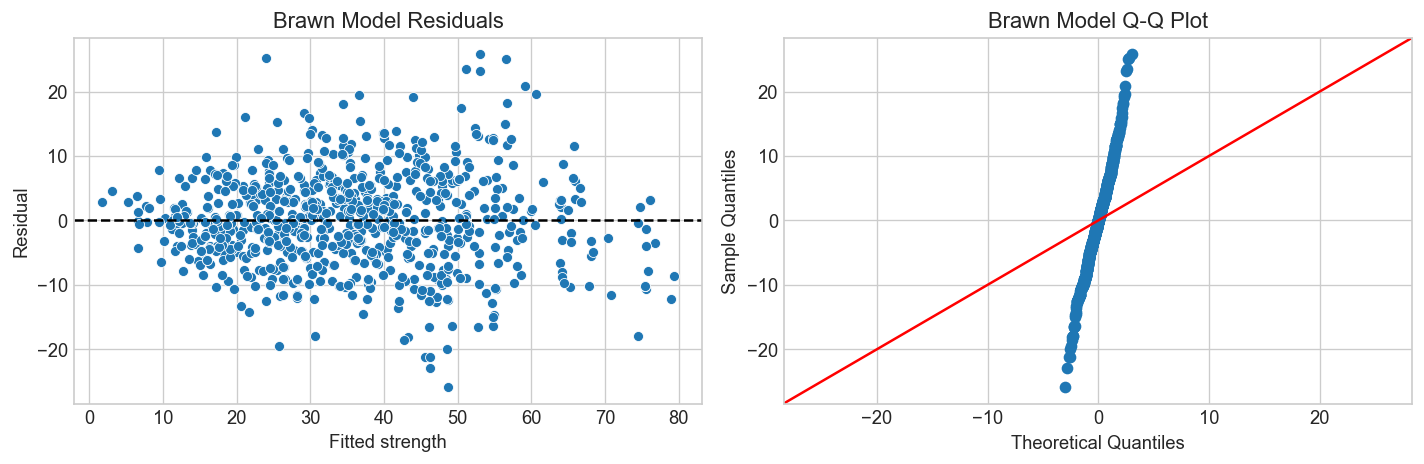

In [20]:
from statsmodels.graphics.gofplots import qqplot

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(x=brawn_model.fittedvalues, y=brawn_model.resid, ax=axes[0])
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("Brawn Model Residuals")
axes[0].set_xlabel("Fitted strength")
axes[0].set_ylabel("Residual")

qqplot(brawn_model.resid, line="45", ax=axes[1])
axes[1].set_title("Brawn Model Q-Q Plot")

plt.tight_layout()
plt.show()

- **Residuals versus fitted values:** The residuals are centered approximately around zero, but their spread and several outliers show that substantial variation remains unexplained. This indicates that even the flexible brawn model does not capture every source of strength variation.

- **Q-Q plot:** The residuals depart noticeably from the reference line, especially in the tails. This suggests non normal residual behavior and possible outliers. Normality matters most for small sample coefficient inference; for this assignment's predictive comparison, the more important check is whether a model performs well on the held out test set.

These patterns motivate trying a small number of scientifically interpretable features rather than adding another large collection of interactions.

## 2b. Feature Engineering and Variable Selection

Develop a small number of features based on the concrete data, the residual plots, and the supplied background material. Explain the reason for each feature before fitting the candidate models.

Concrete strength generally increases as the material cures, but the gains are often larger at early ages and diminish later. The age plot below motivates a logarithmic age feature, `log_age`, which can represent this nonlinear curing pattern more parsimoniously than many interaction terms.

Mixture features are also useful because concrete performance depends on the balance among ingredients, not only their separate quantities. The water to binder ratio, where binder is cement plus slag plus fly ash, is a standard interpretable measure of the amount of water relative to cementitious material. The superplasticizer to binder ratio represents admixture dosage relative to binder, and the aggregate to binder ratio summarizes the coarse and fine aggregate relative to the cementitious phase.

These choices are consistent with the curing discussion in [Fly Ash Facts for Highway Engineers](https://www.fhwa.dot.gov/pavement/recycling/fach03.cfm) and the statistical model discussion in [Modeling of Strength of High Performance Concrete Using Artificial Neural Networks](https://www.researchgate.net/publication/222447231_Modeling_of_Strength_of_High Performance_Concrete_Using_Artificial_Neural_Networks_Cement_and_Concrete_research_2812_1797-1808). The references motivate the features; the plots and held out test set determine whether they help this dataset.

The candidate models below keep the original main effects and add these features one group at a time. This makes the AIC comparisons interpretable and limits unnecessary complexity.

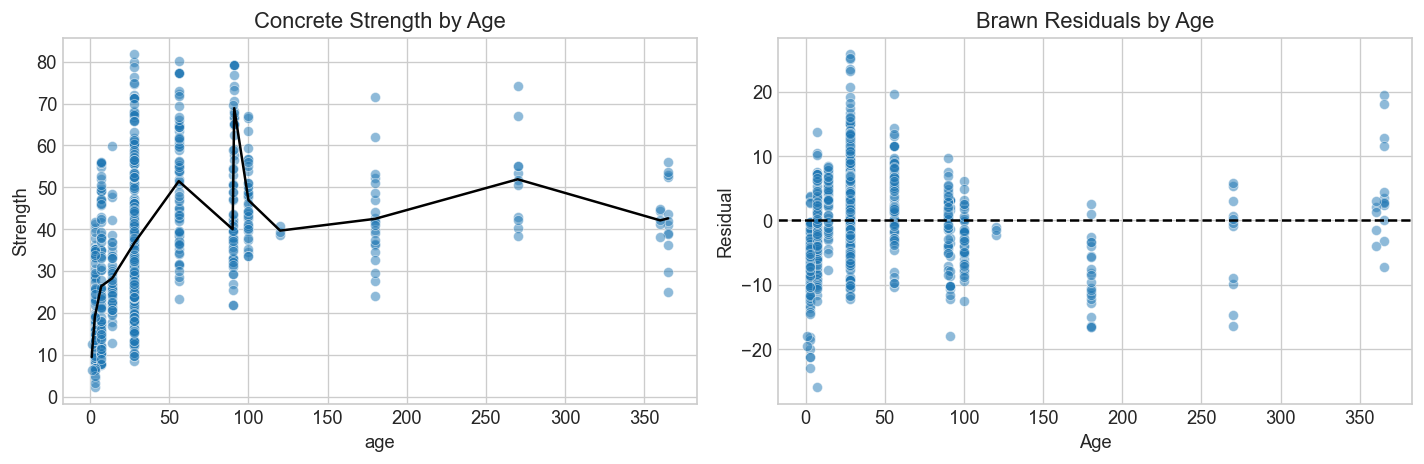

In [21]:
# Compare the curing trend with the brawn model residual pattern.
age_column = "age"
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=concrete_train, x=age_column, y="strength", alpha=0.5, ax=axes[0])
sns.lineplot(
    data=concrete_train.sort_values(age_column),
    x=age_column,
    y="strength",
    estimator="mean",
    errorbar=None,
    color="black",
    ax=axes[0],
 )
axes[0].set_title("Concrete Strength by Age")
axes[0].set_ylabel("Strength")

sns.scatterplot(
    x=concrete_train[age_column],
    y=brawn_model.resid,
    alpha=0.5,
    ax=axes[1],
 )
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Brawn Residuals by Age")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

In [22]:
# Engineer interpretable curing and mixture balance features.
concrete_train_engineered = concrete_train.copy()
concrete_test_engineered = concrete_test.copy()

for data in (concrete_train_engineered, concrete_test_engineered):
    binder = data["cement"] + data["slag"] + data["ash"]
    data["log_age"] = np.log(data[age_column])
    data["sqrt_age"] = np.sqrt(data[age_column])
    data["water_binder_ratio"] = data["water"] / binder
    data["superplasticizer_binder_ratio"] = data["superplasticizer"] / binder
    data["aggregate_binder_ratio"] = (data["coarse"] + data["fine"]) / binder

candidate_formulas = {
    "Main effects": "strength ~ " + " + ".join(predictors),
    "Log age": "strength ~ " + " + ".join(predictors) + " + log_age",
    "Square root age": "strength ~ " + " + ".join(predictors) + " + sqrt_age",
    "Log age + mixture ratios": (
        "strength ~ " + " + ".join(predictors)
        + " + log_age + water_binder_ratio"
        + " + superplasticizer_binder_ratio + aggregate_binder_ratio"
    ),
}

candidate_models = {}
candidate_aic = []
for name, formula in candidate_formulas.items():
    model = smf.ols(formula, data=concrete_train_engineered).fit()
    candidate_models[name] = model
    candidate_aic.append({
        "model": name,
        "parameters": len(model.params),
        "aic": model.aic,
        "r_squared": model.rsquared,
    })

candidate_aic_table = (
    pd.DataFrame(candidate_aic)
    .sort_values("aic")
    .round({"aic": 2, "r_squared": 3})
 )
candidate_aic_table

,model,parameters,aic,r_squared
3,Log age + mixture ratios,13,5540.89,0.828
1,Log age,10,5549.87,0.825
2,Square root age,10,5577.58,0.819
0,Main effects,9,6189.17,0.617


Compare the candidate models using AIC. Keep the feature set small and explain why each retained feature is useful.

### Conclusion

The candidate comparison supports retaining `log_age` and the three mixture ratio features. The log age model has a lower AIC than the main effects model, which indicates that the diminishing strength gains associated with curing are better represented by a logarithmic transformation than by a simple linear age effect. The square root age model performs worse than the log age model, so it is not retained.

The model combining `log_age`, `water_binder_ratio`, `superplasticizer_binder_ratio`, and `aggregate_binder_ratio` has the lowest AIC among the candidates, `5540.891`, and an $R^2$ of approximately `0.828`. This improvement is consistent with the idea that strength depends on both curing time and the balance of water, binder, admixture, and aggregate in the mixture. The feature set remains small and interpretable compared with the 45-parameter brawn model.

AIC measures fit with a penalty for model size, so this result identifies the preferred training data candidate rather than proving better prediction on new observations. The test set MSE and RMSE in Section 2c provide the final check of whether the engineered model generalizes better than the brawn model.

## 2c. Test Set Evaluation

Evaluate the brawn model and the engineered models on the test data. Use a common metric such as mean squared error and compare the out of sample rankings with the rankings based on training AIC.

In [23]:
from sklearn.metrics import mean_squared_error

model_predictions = {"Brawn model": brawn_model.predict(concrete_test)}
for name, model in candidate_models.items():
    model_predictions[name] = model.predict(concrete_test_engineered)

comparison = []
for name, predictions in model_predictions.items():
    mse = mean_squared_error(concrete_test["strength"], predictions)
    comparison.append({
        "model": name,
        "test_mse": mse,
        "test_rmse": np.sqrt(mse),
    })

test_comparison = (
    pd.DataFrame(comparison)
    .sort_values("test_mse")
    .round({"test_mse": 2, "test_rmse": 2})
 )
test_comparison

,model,test_mse,test_rmse
4,Log age + mixture ratios,46.11,6.79
2,Log age,46.83,6.84
3,Square root age,48.62,6.97
0,Brawn model,61.62,7.85
1,Main effects,107.73,10.38


If the AIC ranking and test set ranking disagree, calculate corrected AIC using:

$$
\mathrm{AICc} = \mathrm{AIC} + \frac{2k(k+1)}{n-k-1},
$$

where $k$ is the number of model parameters and $n$ is the number of training observations.

In [24]:
def aicc(model, n):
    parameter_count = len(model.params)
    return model.aic + (
        2 * parameter_count * (parameter_count + 1)
        / (n - parameter_count - 1)
    )

model_summary = {"Brawn model": brawn_model}
model_summary.update(candidate_models)

aicc_table = pd.DataFrame([
    {
        "model": name,
        "aic": model.aic,
        "aicc": aicc(model, len(concrete_train)),
        "parameters": len(model.params),
    }
    for name, model in model_summary.items()
]).sort_values("aicc")

aicc_table.round({"aic": 2, "aicc": 2})

,model,aic,aicc,parameters
4,Log age + mixture ratios,5540.89,5541.34,13
2,Log age,5549.87,5550.14,10
3,Square root age,5577.58,5577.86,10
0,Brawn model,5672.43,5677.77,45
1,Main effects,6189.17,6189.39,9


### Conclusion

The held out test set confirms the training data comparison. The **log age plus mixture ratio model** has the best predictive performance, with a test MSE of `46.11` and RMSE of `6.79`. It also improves on the log age only model, indicating that the mixture balance features add information beyond curing time.

The brawn model has a test MSE of `61.62` and RMSE of `7.85`, despite its flexible 45-parameter specification. Its weaker test performance relative to the smaller engineered model is evidence of overfitting: the additional interactions and squared terms improve flexibility without improving generalization here.

For this dataset, I would use the engineered model for prediction because it combines the strongest test set performance with interpretable features and a lower complexity specification. The final choice is based on held out performance, not on training $R^2$ alone.


## Main Findings

### Earnings analysis

The earnings outcome is strongly right skewed, so the analysis models `log_earnk` after restricting to respondents with positive earnings. This transformation improves the scale for linear modeling, but it also changes the target population: the results do not describe respondents with zero or missing earnings.

Height and weight each show positive one predictor associations with earnings, but neither coefficient should be interpreted as a causal effect. Because height and weight are correlated measures of body size, including both predictors makes their separate effects less precise. Adding education changes the estimated body size associations and explains additional variation, which is consistent with education being an important socioeconomic covariate. The collider discussion further shows why selection on positive earnings and nonrandom missingness can complicate causal interpretation.

### Concrete strength analysis

The brawn model provides a deliberately flexible baseline using all main effects, squared terms, and pairwise interactions. Its complexity improves flexibility but also creates a risk of overfitting. The engineered models use a smaller set of scientifically motivated features: a logarithmic age term for diminishing curing gains and ratios that describe the balance of water, admixture, aggregate, and binder.

The **log age plus mixture ratio model** is the preferred predictive model. It has the lowest AIC (`5540.89`) and AICc (`5541.34`), and it performs best on the held out test set with MSE `46.11` and RMSE `6.79`. The brawn model has a higher test MSE of `61.62`, so its more complicated specification does not generalize as well here.

## Model Choices and Limitations

For earnings, the one predictor and adjusted regressions are useful for describing conditional associations, not for establishing causal effects. For concrete strength, the engineered model is the best choice for prediction because its selection is supported by both information criteria and unseen test data.

These conclusions are limited to the supplied samples and feature measurements. The concrete analysis evaluates predictive performance, not the causal effect of changing an ingredient, because the data are not from a randomized experiment. Likewise, the earnings analysis is limited to positive earners and depends on assumptions about confounding, selection, and missingness.